In [1]:
import os
import cdflib
import numpy as np
from numpy.ma import masked_array
import pandas as pd
import scienceplots
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.interpolate import interp1d
from scipy.signal import butter, filtfilt
from scipy import constants
import seaborn as sns

In [2]:
mp = constants.m_p
Kb = constants.Boltzmann
mu_0 = constants.mu_0

In [3]:
def calculate_zplus(row, theta_col, VT_col, Va_col):
    if row[theta_col] <= 90:
        return row[VT_col] - row[Va_col]
    else:
        return row[VT_col] + row[Va_col]
    
def calculate_zminus(row, theta_col, VT_col, Va_col):
    if row[theta_col] <= 90:
        return row[VT_col] + row[Va_col]
    else:
        return row[VT_col] - row[Va_col]

In [4]:
my_folder = r"C:\Users\shubham kadam\Dropbox\My PC (LAPTOP-EVH7N8LC)\Documents\solo.2023\wind_data\mag_03_19_2023"
if not os.path.isdir(my_folder):
    print(f"Error: The following folder does not exist: {my_folder}")
   

file_pattern = os.path.join(my_folder, '*.cdf')
cdf_files = [file for file in os.listdir(my_folder) if file.endswith('.cdf')]

data_frames = []
for file_name in cdf_files:
    full_file_name = os.path.join(my_folder, file_name)
    print(f"Now reading {full_file_name}")

    with cdflib.CDF(full_file_name) as cdf:
        epoch_cdf = cdf['Epoch'][:]
        epoch_datetime = pd.to_datetime(cdflib.cdfepoch.to_datetime(epoch_cdf))
        data = {
            'Epoch': epoch_datetime,
            'Bx': cdf['B_RTN'][:, 0],
            'By': cdf['B_RTN'][:, 1],
            'Bz': cdf['B_RTN'][:, 2]
        }
        df = pd.DataFrame(data)
        data_frames.append(df)
        
df_mag = pd.concat(data_frames, ignore_index=True)
df_mag['BT'] = np.sqrt(df_mag['Bx']**2 + df_mag['By']**2 + df_mag['Bz']**2)

Now reading C:\Users\shubham kadam\Dropbox\My PC (LAPTOP-EVH7N8LC)\Documents\solo.2023\wind_data\mag_03_19_2023\solo_l2_mag-rtn-normal-1-minute_20230319_v01.cdf


In [5]:
my_folder = r"C:\Users\shubham kadam\Dropbox\My PC (LAPTOP-EVH7N8LC)\Documents\solo.2023\wind_data\swa_03_19_2023"
if not os.path.isdir(my_folder):
    print(f"Error: The following folder does not exist: {my_folder}")
   

file_pattern = os.path.join(my_folder, '*.cdf')
cdf_files = [file for file in os.listdir(my_folder) if file.endswith('.cdf')]

data_frame_swa = []
for file_name in cdf_files:
    full_file_name = os.path.join(my_folder, file_name)
    print(f"Now reading {full_file_name}")

    with cdflib.CDF(full_file_name) as cdf:
        epoch_cdf = cdf['Epoch'][:]
        epoch_datetime = pd.to_datetime(cdflib.cdfepoch.to_datetime(epoch_cdf))
        data = {
            'Epoch': epoch_datetime,
            'Density': cdf['N'][:],
            'Temperature': cdf['T'][:],
            'Vx': cdf['V_RTN'][:, 0],
            'Vy': cdf['V_RTN'][:, 1],
            'Vz': cdf['V_RTN'][:, 2]
        }
        df = pd.DataFrame(data)
        data_frame_swa.append(df)
        
df_swa = pd.concat(data_frame_swa, ignore_index=True)
df_swa['VT'] = np.sqrt(df_swa['Vx']**2 + df_swa['Vy']**2 + df_swa['Vz']**2)

Now reading C:\Users\shubham kadam\Dropbox\My PC (LAPTOP-EVH7N8LC)\Documents\solo.2023\wind_data\swa_03_19_2023\solo_l2_swa-pas-grnd-mom_20230319_v02.cdf


In [11]:
df_mag_ext = df_mag[(df_mag['Epoch'] >= pd.to_datetime('2023/03/19 00:00:00.000')) & (df_mag['Epoch'] <=  pd.to_datetime('2023/03/19 12:00:00.000'))].copy()
df_swa_ext = df_swa[(df_swa['Epoch'] >= pd.to_datetime('2023/03/19 00:00:00')) & (df_swa['Epoch'] <=  pd.to_datetime('2023/03/19 12:00:00'))].copy()

In [12]:
df_swa_resam = df_swa_ext.set_index('Epoch')
df_swa_resam = df_swa_resam.resample('4S').mean().reset_index()

C:\Users\shubham kadam\AppData\Local\Temp\ipykernel_15120\3079018310.py:2: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df_swa_resam = df_swa_resam.resample('4S').mean().reset_index()


In [13]:
time_mag = df_mag_ext['Epoch']
time_swa = df_swa_resam['Epoch']

In [14]:
time_max = time_swa.max()
time_min = time_swa.min()

In [15]:
time_range = pd.date_range(start = time_min, end = time_max, freq = '4S')

C:\Users\shubham kadam\AppData\Local\Temp\ipykernel_15120\888867046.py:1: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  time_range = pd.date_range(start = time_min, end = time_max, freq = '4S')


In [16]:
interp_mag = []

for t in time_range:
    idx = np.argmin(np.abs(t - time_mag))
    if abs((t - time_mag[idx]).total_seconds()) <= 4:
        row_values = df_mag_ext.iloc[idx, 1:].tolist()
        interp_mag.append((t,) + tuple(row_values))
    else:
        interp_mag.append((t,) + (np.nan,) * (len(df_mag_ext.columns) - 1))
        
df_mag_resam = pd.DataFrame(interp_mag, columns=df_mag_ext.columns)

In [17]:
merged_df = pd.merge(df_swa_resam,df_mag_resam,on='Epoch')

In [18]:
merged_df = merged_df.set_index('Epoch')

In [19]:
merged_df = merged_df.interpolate(method='time')

In [20]:
fs = 0.25  
order = 4
fcutlow = 0.0001
fcuthigh = 0.1
nyquist = 0.5 * fs
b, a = butter(order, [fcutlow / nyquist, fcuthigh / nyquist], btype='band')

In [21]:
df_filtered = merged_df.copy()
for col in ['Bx', 'By', 'Bz', 'Vx', 'Vy', 'Vz', 'VT', 'BT']:   #'Density', 
    df_filtered[col] = filtfilt(b, a, merged_df[col].values)

In [22]:
df_filtered['Density'] = np.abs(merged_df['Density'])
df_filtered['Vax'] = (df_filtered['Bx'] / np.sqrt(4 * np.pi * 1.6726219 * merged_df['Density'])) * 10**2
df_filtered['Vay'] = (df_filtered['By'] / np.sqrt(4 * np.pi * 1.6726219 * merged_df['Density'])) * 10**2
df_filtered['Vaz'] = (df_filtered['Bz'] / np.sqrt(4 * np.pi * 1.6726219 * merged_df['Density'])) * 10**2
df_filtered['theta'] = np.degrees(np.arccos(df_filtered['Bx']/ (df_filtered['BT'])))

In [23]:
df_filtered['z_plus_x'] = df_filtered.apply(calculate_zplus, args=('theta', 'Vx', 'Vax'), axis=1)
df_filtered['z_plus_y'] = df_filtered.apply(calculate_zplus, args=('theta', 'Vy', 'Vay'), axis=1)
df_filtered['z_plus_z'] = df_filtered.apply(calculate_zplus, args=('theta', 'Vz', 'Vaz'), axis=1)

df_filtered['z_minus_x'] = df_filtered.apply(calculate_zminus, args=('theta', 'Vx', 'Vax'), axis=1)
df_filtered['z_minus_y'] = df_filtered.apply(calculate_zminus, args=('theta', 'Vy', 'Vay'), axis=1)
df_filtered['z_minus_z'] = df_filtered.apply(calculate_zminus, args=('theta', 'Vz', 'Vaz'), axis=1)

In [24]:
df_filtered['z_plus_total'] = np.sqrt(df_filtered['z_plus_x']**2 + df_filtered['z_plus_y']**2 
                                      + df_filtered['z_plus_z']**2)

df_filtered['z_minus_total'] = np.sqrt(df_filtered['z_minus_x']**2 + df_filtered['z_minus_y']**2
                                       + df_filtered['z_minus_z']**2)

In [25]:
df_filtered['eplustotal'] = 0.5 * (df_filtered['z_plus_total'] ** 2)
df_filtered['eminustotal'] = 0.5 * (df_filtered['z_minus_total'] ** 2)
df_filtered['sigma_c'] = (df_filtered['eplustotal'] - df_filtered['eminustotal'])/(df_filtered['eminustotal'] + df_filtered['eplustotal'])
df_filtered['re'] = df_filtered['eminustotal']/df_filtered['eplustotal']

In [26]:
df_filtered['Va_T'] = np.sqrt(df_filtered['Vax']**2 + df_filtered['Vay']**2 + df_filtered['Vaz']**2)
df_filtered['ev'] = 0.5 * df_filtered['VT']**2
df_filtered['eva'] = 0.5 * df_filtered['Va_T']**2
df_filtered['e_tot'] = df_filtered['ev'] + df_filtered['eva']
df_filtered['e_r'] = df_filtered['ev'] - df_filtered['eva']
df_filtered['sigma_r']  = df_filtered['e_r']/df_filtered['e_tot']
df_filtered['r_a']  = (1+df_filtered['sigma_r'])/(1-df_filtered['sigma_r'])

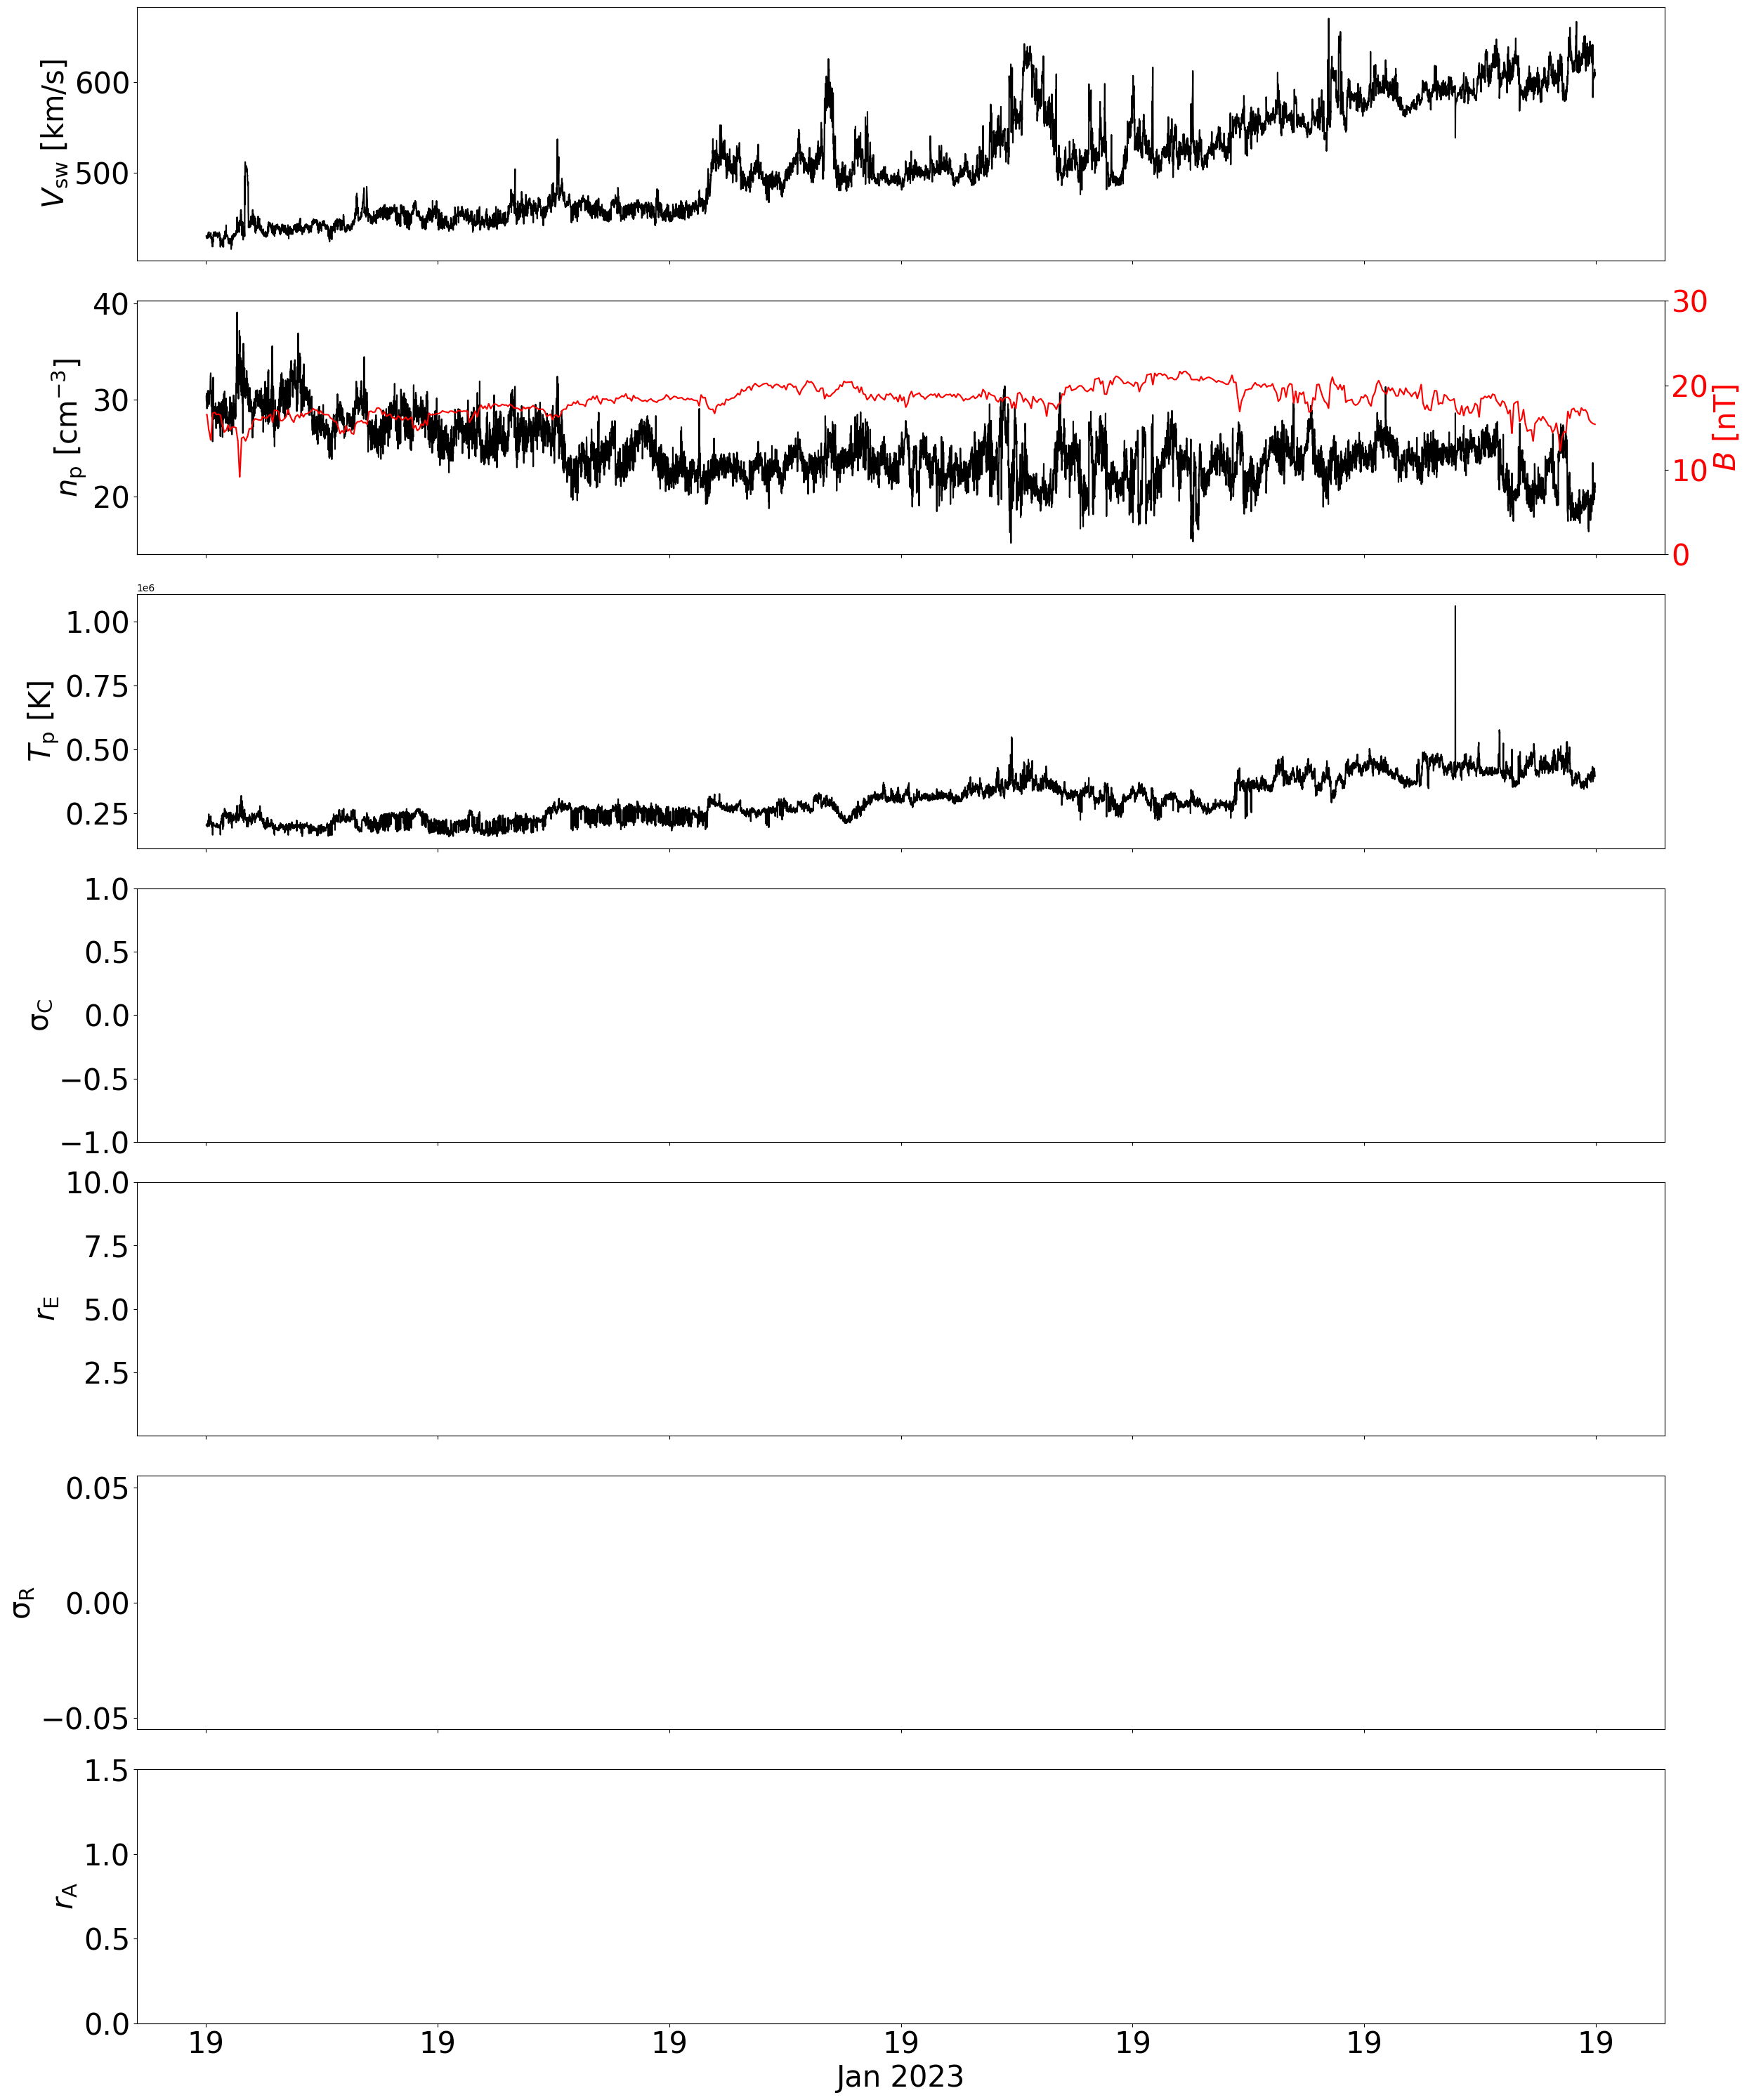

In [30]:
fig, ax = plt.subplots(7, 1, figsize=(25, 30), sharex=True)

ax[0].plot(merged_df.index, merged_df['VT'], color='black')
ax[0].set_ylabel('$V_{\mathrm{sw}}$ [km/s]', fontsize=30)
ax[0].tick_params(axis='both', which='major', labelsize=30)


ax[1].plot(merged_df.index, merged_df['Density'], 'k-')
ax[1].set_ylabel('$n_{\mathrm{p}}$ [cm$^{-3}$]', fontsize=30, color='k')
ax[1].tick_params(axis='y', which='major', labelcolor='k', labelsize=30)

ax2 = ax[1].twinx()
ax2.plot(merged_df.index, merged_df['BT'], 'r-')
ax2.set_ylabel('$B$ [nT]', fontsize=30, color='r')
ax2.tick_params(axis='y', which='major', labelcolor='r', labelsize=30)
ax2.set_ylim(0, 30)

ax[2].plot(merged_df.index, merged_df['Temperature']*11606, 'k-')
ax[2].set_ylabel('$T_{\mathrm{p}}$ [K]', fontsize=30)
ax[2].tick_params(axis='both', which='major', labelsize=30)


ax[3].plot(merged_df.index, df_filtered['sigma_c'] , 'k-')
ax[3].set_ylabel('$\mathrm{\sigma}_{\mathrm{C}}$', fontsize=30, color='k')
ax[3].tick_params(axis='y', which='major', labelcolor='k', labelsize=30)
ax[3].set_ylim(-1,1)

ax[4].plot(merged_df.index, df_filtered['re'], 'k-')
ax[4].set_ylabel('$r_{\mathrm{E}}$', fontsize=30, color='k')
ax[4].tick_params(axis='y', which='major', labelcolor='k', labelsize=30)
ax[4].set_ylim(0.01,10)
ax[4].tick_params(axis='both', which='major', labelsize=30)

ax[5].plot(merged_df.index, df_filtered['sigma_r'] , 'k-')
ax[5].set_ylabel('$\mathrm{\sigma}_{\mathrm{R}}$', fontsize=30, color='k')
ax[5].tick_params(axis='y', which='major', labelcolor='k', labelsize=30)
 #ax[5].set_ylim(-1,1)

ax[6].plot(merged_df.index, df_filtered['r_a'], 'k-')
ax[6].set_ylabel('$r_{\mathrm{A}}$', fontsize=30, color='k')
ax[6].tick_params(axis='y', which='major', labelcolor='k', labelsize=30)
ax[6].set_ylim(0,1.5)
ax[6].tick_params(axis='both', which='major', labelsize=30)


date_formatter = mdates.DateFormatter('%d')
ax[6].xaxis.set_major_formatter(date_formatter)

ax[6].set_xlabel('Jan 2023', fontsize=30)



plt.tight_layout()
#plt.savefig(r"C:\plot\new plots\ALFVEN_PLOT1_1", dpi = 300)
plt.show()

In [31]:
merged_df['Pth']  = Kb * merged_df['Density']* merged_df['Temperature'] *1e+6*11606
merged_df['Mag_pre'] = ((merged_df['BT']*1e-9)**2)/(2*mu_0)
merged_df['beta'] = merged_df['Pth']/merged_df['Mag_pre']

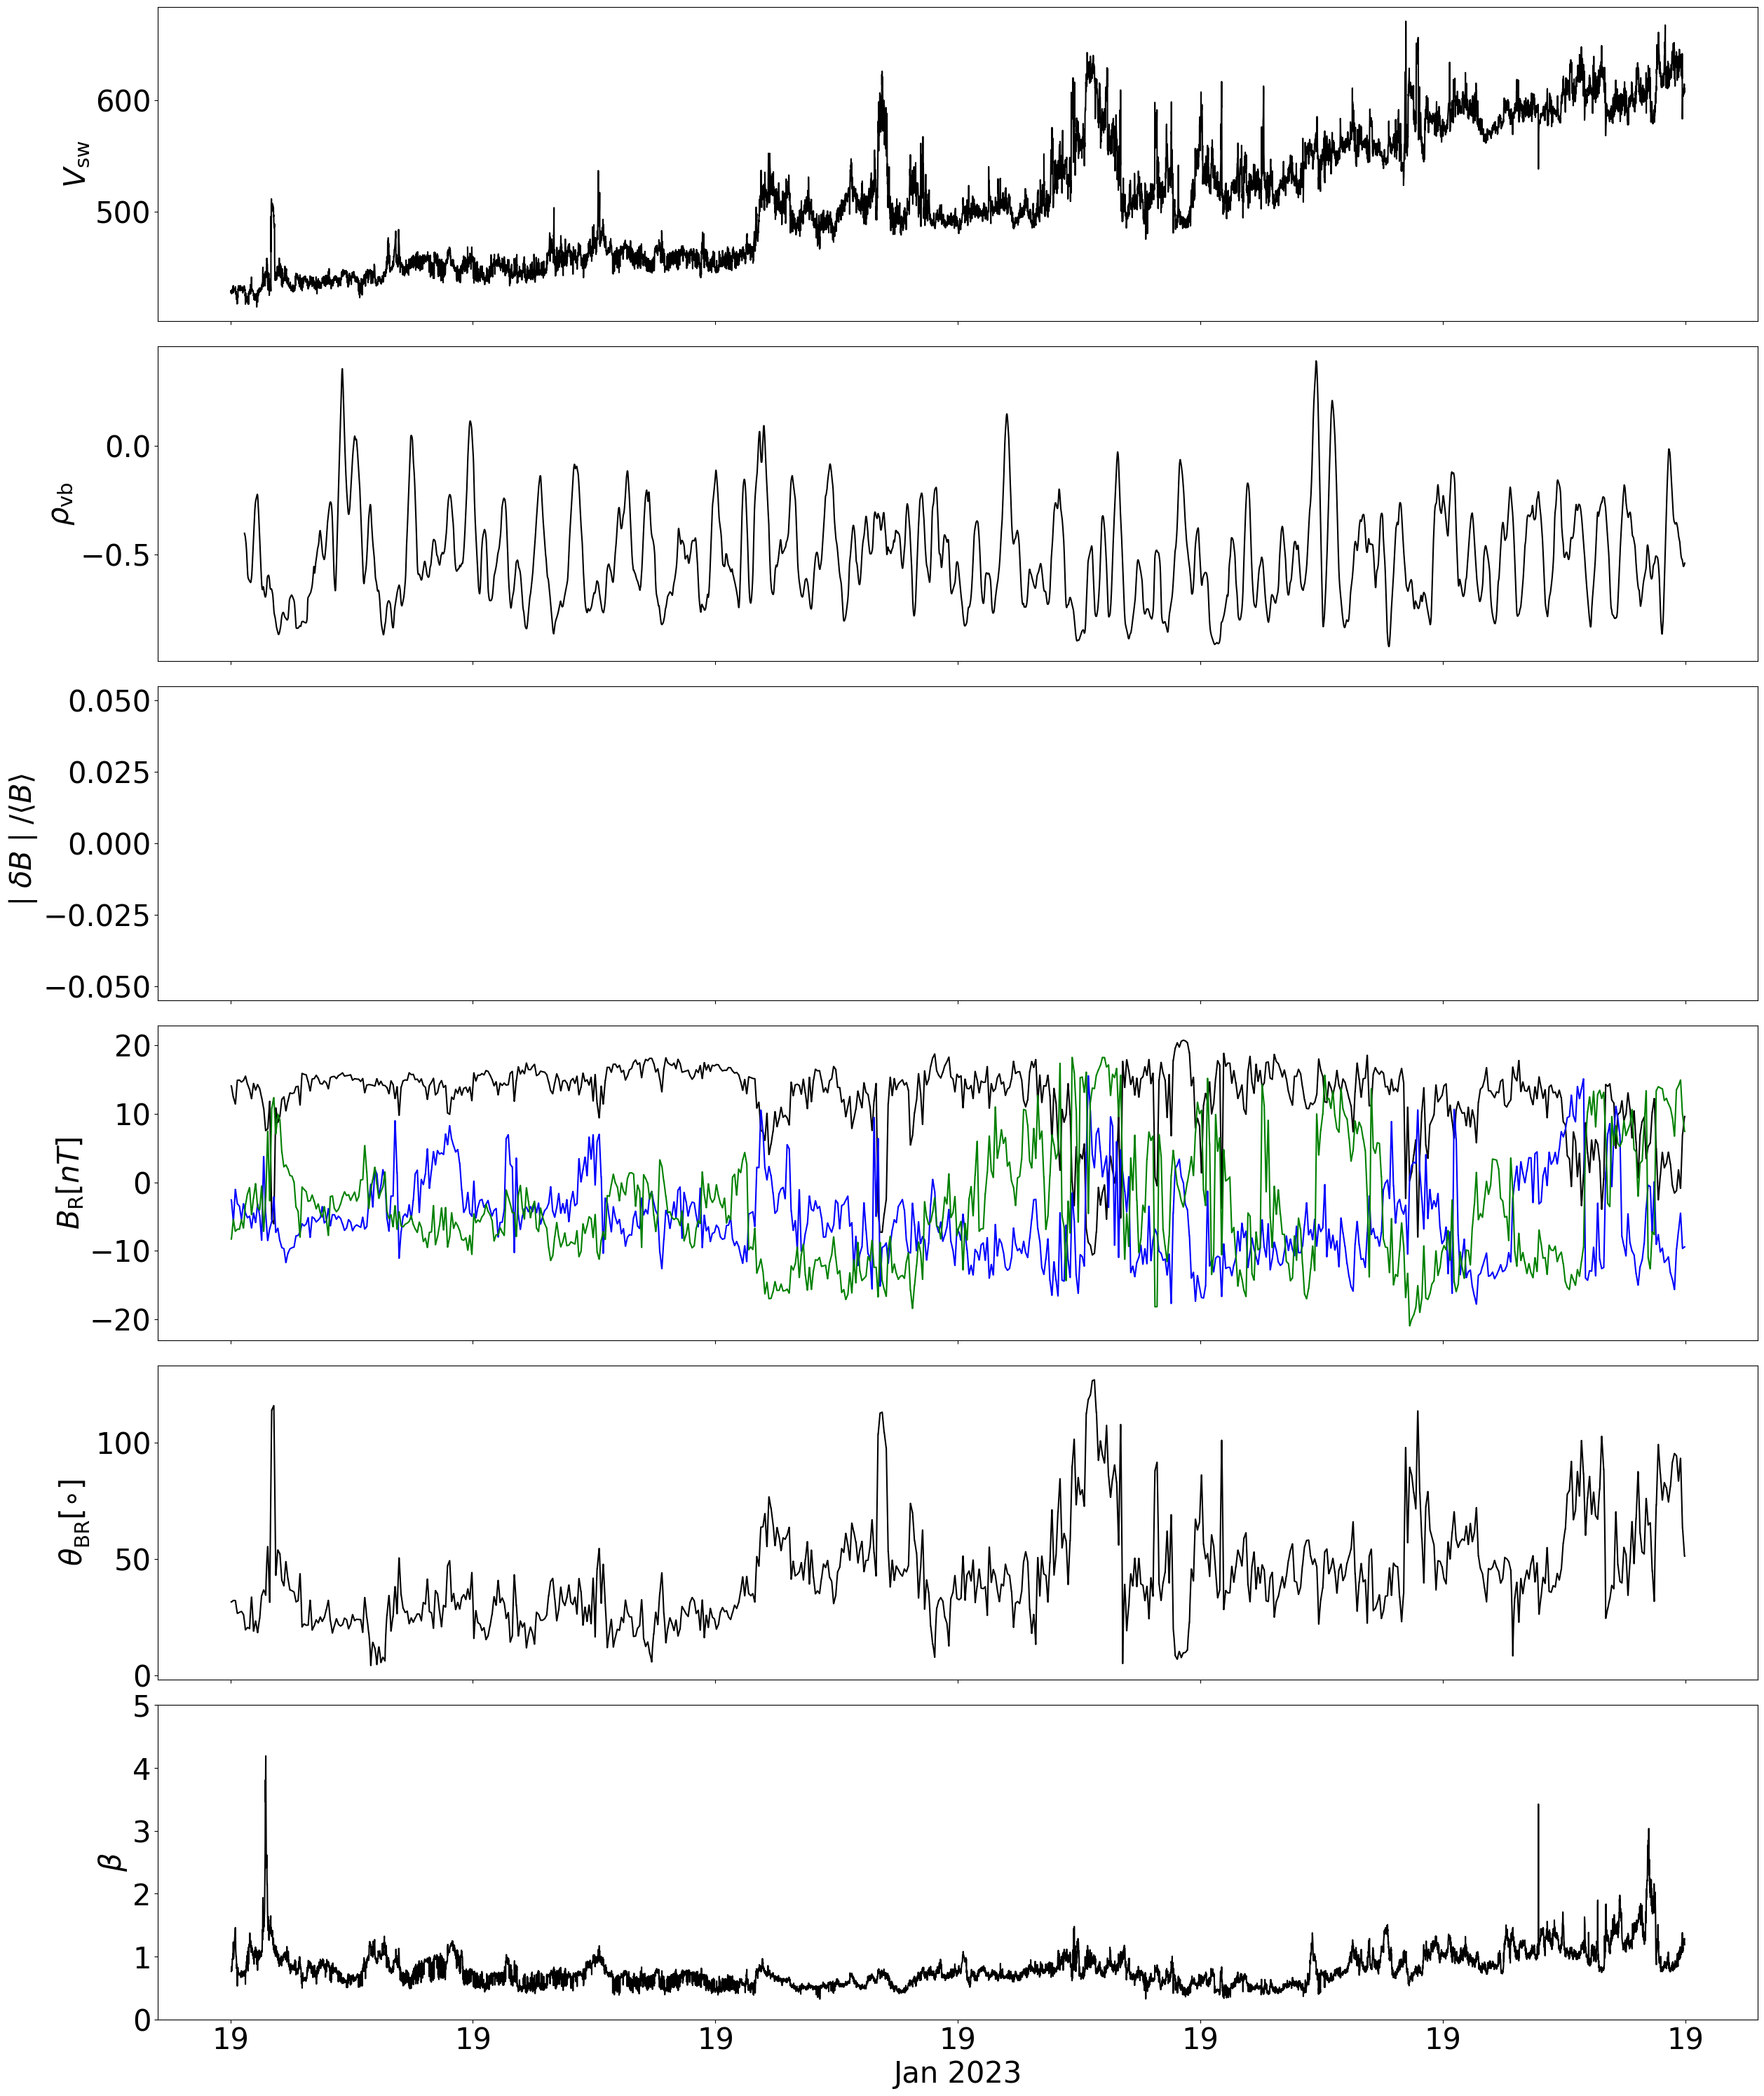

In [35]:
fig, ax = plt.subplots(6, 1, figsize=(25, 30), sharex=True)

ax[0].plot(merged_df.index, merged_df['VT'], color='black')
ax[0].set_ylabel('$V_{\mathrm{sw}}$', fontsize=30)
ax[0].tick_params(axis='both', which='major', labelsize=30)

ax[1].plot(merged_df.index, merged_df['Vz'].rolling(50).corr(merged_df['Bz']).rolling(50).mean(), color = 'black')
ax[1].set_ylabel(r'$\rho_{\mathrm{vb}}$', fontsize=30)
ax[1].tick_params(axis='both', which='major', labelsize=30)


ax[2].plot(merged_df.index, np.sqrt(((merged_df['Bx'] - merged_df['Bx'].iloc[0])**2 + 
                                     (merged_df['By'] - merged_df['By'].iloc[0])**2 + 
                                     (merged_df['Bz'] - merged_df['Bz'].iloc[0])**2)) / np.mean(np.sqrt(merged_df['Bx']**2
                                                                                                        +merged_df['By']**2 + 
                                                                                                        merged_df['Bz']**2)), 
           color = 'black')
ax[2].set_ylabel(r'$\mid \delta B \mid / \langle B \rangle$', fontsize=30)
ax[2].tick_params(axis='both', which='major', labelsize=30)

ax[3].plot(merged_df.index, merged_df['Bx'], color='black')
ax[3].plot(merged_df.index, merged_df['By'], color='blue')
ax[3].plot(merged_df.index, merged_df['Bz'], color='green')
ax[3].set_ylabel('$B_{\mathrm{R}} [nT]$', fontsize=30)
ax[3].tick_params(axis='both', which='major', labelsize=30)

ax[4].plot(merged_df.index, np.degrees(np.arccos(merged_df['Bx']/ np.abs(merged_df['BT']))), color='black')
ax[4].set_ylabel(r'$\theta_{\mathrm{BR}} ^ {\mathrm{[\circ]}}$', fontsize=30)
ax[4].tick_params(axis='both', which='major', labelsize=30)

ax[5].plot(merged_df.index,merged_df['beta'] , color='black')
ax[5].set_ylabel(r'$\beta$', fontsize=30)
ax[5].tick_params(axis='both', which='major', labelsize=30)
ax[5].set_ylim(0,5)



date_formatter = mdates.DateFormatter('%d')
ax[5].xaxis.set_major_formatter(date_formatter)

ax[5].set_xlabel('Jan 2023', fontsize=30)



plt.tight_layout()
# plt.savefig(r"C:\plot\new plots\IP_PLOT1_1", dpi = 300)
plt.show()

In [ ]:
sigma_c = df_filtered['sigma_c'].values
sigma_r = df_filtered['sigma_r'].values

In [69]:
H, xedges, yedges = np.histogram2d(sigma_c, sigma_r, bins=(50, 50))

In [70]:
H = H / H.max()

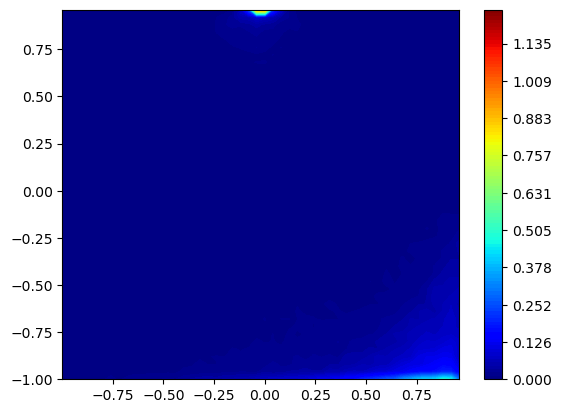

In [74]:
fig, ax = plt.subplots()

# Create the contour plot
X, Y = np.meshgrid(xedges[:-1], yedges[:-1])
contour = ax.contourf(X, Y, H.T, levels=np.linspace(0, 1.25, 110), cmap='jet')


cbar = plt.colorbar(contour)
# ax.set_xlim(0, 1.25)
# ax.set_ylim(-1, 0.25)
plt.show()